# Estructuración y Primer Acercamiento al Dataset
## Luces Nocturnas Satelitales y Machine Learning para la Predicción del IPM en la Región Caribe Colombiana (2018–2024)

**Autores:** Juan C. Aguirre & Camilo V. Escorcia — Universidad del Norte, Barranquilla  
**Fuente de datos:** DANE — Encuesta de Calidad de Vida (ECV), microdatos anuales 2018–2024  
**Alcance geográfico:** Región Caribe colombiana (7 departamentos)  

---

## Contexto del Proyecto

La pobreza multidimensional en Colombia trasciende la insuficiencia de ingresos: refleja privaciones simultáneas en educación, salud, empleo y condiciones de vivienda. El **Índice de Pobreza Multidimensional (IPM)**, desarrollado por Alkire y Foster (2011) y adoptado oficialmente por el DANE, cuantifica estas privaciones a nivel de hogar mediante un umbral de clasificación del 33 %.

La Región Caribe colombiana concentra algunas de las brechas territoriales más pronunciadas del país. A pesar de las mejoras en indicadores agregados, persisten desigualdades intraurbanas e intermunicipales que los promedios nacionales tienden a enmascarar. Este proyecto propone una metodología multimodal —combinando microdatos oficiales del DANE con señales satelitales nocturnas VIIRS— para estimar y predecir el IPM a escala departamental entre 2018 y 2024.

Este primer notebook establece la base del proyecto: carga, limpieza, validación y caracterización estructural del dataset principal.

---

## Estructura de la sección

- 1.1 Configuración del entorno y funciones auxiliares de visualización  
- 1.2 Diccionario de variables  
- 1.3 Carga y primeras inspecciones del dataset  
- 1.4. Corrección de tipos de datos  
- 1.5 Estadísticas descriptivas de variables continuas y categóricas  
- 1.6 Validación de calidad: nulos y duplicados  
- 1.7 Análisis de cobertura temporal y geográfica  
- 1.8 Análisis de multicolinealidad entre variables de privación


---
## 1.0 Configuración del Entorno

Se importan las librerías necesarias para manipulación de datos y visualización. Se definen además dos funciones de visualización reutilizables que se aplicarán a lo largo de todos los notebooks del proyecto:

- `plot_privacion`: visualiza la distribución binaria (privación / no privación) de una variable individual con frecuencias y proporciones.
- `plot_evolucion_y_departamento`: genera una vista doble — comparativa departamental y evolución temporal — para cualquier variable indicadora del IPM. Incluye marcador del año 2020 como punto de quiebre estructural asociado a la pandemia COVID-19.

> Estas funciones estandarizan el estilo visual en todos los notebooks del proyecto, garantizando coherencia en la presentación de resultados.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración global de visualización
# Se usa la paleta 'viridis' como estándar del proyecto para garantizar
# consistencia visual y accesibilidad en todas las figuras.
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

VIRIDIS = plt.cm.viridis
COLOR_NO_PRIV = '#3B528B'  # Azul-violeta viridis — No privación
COLOR_PRIV    = '#FDE725'  # Amarillo viridis    — Privación
COVID_YEAR    = 2020       # Año de quiebre estructural por pandemia

print("Entorno configurado correctamente.")
print(f"Pandas {pd.__version__} | NumPy {np.__version__} | Matplotlib {plt.matplotlib.__version__}")


Entorno configurado correctamente.
Pandas 2.3.3 | NumPy 2.3.5 | Matplotlib 3.10.7


In [2]:
def plot_privacion(df, variable, titulo):
    """
    Visualiza la distribución de una variable binaria de privación.

    Muestra frecuencia absoluta y proporción relativa de los estados
    'No privación' y 'Privación' para una variable indicadora del IPM.

    Parámetros
    ----------
    df       : pd.DataFrame — dataset del IPM
    variable : str          — nombre de la columna binaria (0/1)
    titulo   : str          — título descriptivo para el gráfico
    """
    conteo = df[variable].value_counts().sort_index()
    conteo.index = ["No privación", "Privación"]
    proporcion = conteo / conteo.sum()

    # Paleta viridis para los dos estados
    colors = [COLOR_NO_PRIV, COLOR_PRIV]

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor('#F7F9FC')

    bars = ax.bar(conteo.index, conteo.values, color=colors, edgecolor='white', linewidth=0.8)

    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Estado de Privación", fontsize=11)
    ax.set_ylabel("Frecuencia Absoluta", fontsize=11)

    # Etiqueta: frecuencia sobre la barra y proporción dentro
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                f"{int(height):,}", ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.text(bar.get_x() + bar.get_width() / 2, height / 2,
                f"{proporcion.iloc[i]:.1%}", ha='center', va='center', fontsize=10,
                color='white', fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.3, boxstyle='round,pad=0.3', edgecolor='none'))

    plt.tight_layout()
    plt.show()


In [3]:
def plot_evolucion_y_departamento(df, variable, titulo):
    """
    Genera una visualización dual para variables indicadoras del IPM:
      - Panel izquierdo: proporción de privación por departamento (barras apiladas).
      - Panel derecho: evolución temporal de la privación con marcador COVID-19.

    Permite comparar heterogeneidad territorial y trayectorias temporales
    en una sola figura, facilitando la identificación de patrones regionales.

    Parámetros
    ----------
    df       : pd.DataFrame — dataset del IPM
    variable : str          — columna binaria de privación
    titulo   : str          — etiqueta descriptiva de la variable
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.patch.set_facecolor('#F7F9FC')

    # ── Panel izquierdo: distribución por departamento ──────────────────────
    tabla = pd.crosstab(df['departamento_nombre'], df[variable], normalize='index')
    tabla.columns = ['No privación', 'Privación']
    tabla = tabla.sort_values('Privación', ascending=True)

    tabla.plot(kind='barh', stacked=True, ax=axes[0],
               color=[COLOR_NO_PRIV, COLOR_PRIV], edgecolor='white')

    axes[0].set_title(f"{titulo} por Departamento", fontsize=13, fontweight='bold', pad=10)
    axes[0].set_xlabel("Proporción", fontsize=11)
    axes[0].set_ylabel("Departamento", fontsize=11)

    for container in axes[0].containers:
        labels = [f"{v:.1%}" for v in container.datavalues]
        axes[0].bar_label(container, labels=labels, label_type='center', fontsize=8,
                          color='white', fontweight='bold')

    # ── Panel derecho: evolución temporal por departamento ──────────────────
    evolucion = df.groupby(['año', 'departamento_nombre'])[variable].mean().reset_index()

    # Paleta viridis discreta para los departamentos
    departamentos = evolucion['departamento_nombre'].unique()
    palette = [VIRIDIS(i / (len(departamentos) - 1)) for i in range(len(departamentos))]

    for dep, color in zip(departamentos, palette):
        subset = evolucion[evolucion['departamento_nombre'] == dep]
        axes[1].plot(subset['año'], subset[variable],
                     marker='o', linewidth=2, label=dep, color=color)

    # Línea vertical: año de inicio de la pandemia COVID-19
    axes[1].axvline(x=COVID_YEAR, linestyle='dotted', linewidth=2,
                    color='crimson', alpha=0.8, label='COVID-19 (2020)')

    axes[1].set_title(f"Evolución Temporal — {titulo}", fontsize=13, fontweight='bold', pad=10)
    axes[1].set_xlabel("Año", fontsize=11)
    axes[1].set_ylabel("Proporción de Privación", fontsize=11)
    axes[1].legend(title='Departamento', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()


---
## 1.2 Diccionario de Variables

El dataset integra variables del módulo de Condiciones de Vida de la ECV del DANE para los 7 departamentos de la Región Caribe. Las variables indicadoras del IPM son **binarias (0/1)**: el valor `1` indica presencia de privación en esa dimensión para al menos un miembro del hogar.

El IPM se estructura en **cinco dimensiones** con ponderaciones iguales (20 % cada una), de acuerdo con la metodología de Alkire y Foster adoptada por el DANE (Angulo, Pardo y Díaz, 2011):

| Dimensión | Variable | Descripción |
|-----------|----------|-------------|
| **Identificadores** | `año` | Año de referencia de los datos |
| **Identificadores** | `departamento_nombre` | Nombre del departamento |
| **Identificadores** | `region` | Código de la región geográfica |
| **Identificadores** | `personas` | Número de personas en el hogar |
| **Identificadores** | `cuartos_dormir` | Cuartos destinados a dormir |
| **Expansión** | `fex_c` | Factor de expansión a nivel de hogar |
| **Expansión** | `fexp` | Factor de expansión a nivel de persona |
| **Variable objetivo** | `ipm` | Índice de Pobreza Multidimensional (continua, 0–1) |
| **Variable objetivo** | `pobre` | 1 si IPM ≥ 33 %, 0 si no (umbral oficial DANE) |
| **Educación** | `alfabetismo` | Privación: algún miembro mayor de 15 años no sabe leer ni escribir |
| **Educación** | `logro_educativo` | Privación: promedio de años de educación de adultos < 9 años |
| **Educación** | `inasistencia_escolar` | Privación: niño de 6–16 años no asiste a la escuela |
| **Educación** | `rezago_escolar` | Privación: niño de 7–17 años con rezago académico |
| **Niñez y Juventud** | `trabajo_infantil` | Privación: niño de 12–17 años trabaja |
| **Niñez y Juventud** | `atencion_integral` | Privación: niño de 0–5 años sin acceso a atención integral |
| **Trabajo** | `empleo_formal` | Privación: miembro ocupado sin afiliación a pensiones |
| **Trabajo** | `desempleo_larga_duracion` | Privación: miembro desempleado por más de 12 meses |
| **Salud** | `aseguramiento_salud` | Privación: miembro mayor de 5 años sin seguro de salud |
| **Salud** | `barreras_acceso_salud` | Privación: miembro con problema de salud no atendido |
| **Vivienda y Servicios** | `pisos` | Privación: pisos de tierra u otro material inadecuado |
| **Vivienda y Servicios** | `paredes` | Privación: paredes de material inadecuado |
| **Vivienda y Servicios** | `hacinamiento` | Privación: más de 3 personas por cuarto |
| **Vivienda y Servicios** | `alcantarillado` | Privación: sin servicio de alcantarillado |
| **Vivienda y Servicios** | `acueducto` | Privación: sin acceso a acueducto o fuente inadecuada |
| **Vivienda y Servicios** | `tipo_sanitario` | Tipo de servicio sanitario del hogar |
| **Vivienda y Servicios** | `fuente_agua` | Fuente principal de abastecimiento de agua |

> **Nota metodológica:** San Andrés y Providencia no está incluido en el dataset del DANE bajo la categoría de Región Caribe para los años de estudio, por lo que el análisis se limita a los 7 departamentos restantes.


---
## 1.3 Carga y Primeras Inspecciones del Dataset

Los microdatos del IPM provienen de los archivos anuales publicados por el DANE (2018–2024). Los archivos originales presentaban inconsistencias en el nombrado de variables entre periodos y diferencias de formato según el año de publicación. El proceso de integración implicó:

- Concatenación manual de los 7 archivos anuales.
- Estandarización de nombres de columnas y codificaciones de respuesta.
- Verificación de errores de digitación y valores fuera de rango.
- Filtro geográfico para conservar únicamente los departamentos de la Región Caribe.

El archivo resultante `IPM_2018_2024_CLEAN_CARIBE.csv` es el punto de entrada de este notebook.


In [4]:
# Carga del dataset integrado (2018–2024, Región Caribe)
# Separador punto y coma por formato original de exportación del DANE.
# Actualiza la ruta según la ubicación local del archivo.
df = pd.read_csv(
    r"../data/IPM_2018_2024_CLEAN_CARIBE.csv",
    sep=';'
)

print(f"Dataset cargado exitosamente.")
print(f"  Filas:    {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Periodo:  {df['año'].min()} – {df['año'].max()}")
print(f"  Departamentos: {sorted(df['departamento_nombre'].unique())}")


Dataset cargado exitosamente.
  Filas:    135,835
  Columnas: 28
  Periodo:  2018 – 2024
  Departamentos: ['ATLANTICO', 'BOLIVAR', 'CESAR', 'CORDOBA', 'LA GUAJIRA', 'MAGDALENA', 'SUCRE']


In [5]:
# Vista preliminar de los primeros registros
# Permite verificar que la estructura del archivo se cargó correctamente.
df.head()


,cuartos_dormir,tipo_sanitario,fuente_agua,fex_c,region,departamento,personas,paredes,pisos,alcantarillado,...,rezago_escolar,alfabetismo,logro_educativo,hacinamiento,ipm,pobre,fexp,region_nombre,departamento_nombre,año
0,2,1,1,"384,3281693",1,8,2,0,0,0,...,0,0,0,0,"0,1",0,"768,6563387",Caribe,ATLANTICO,2018
1,2,1,1,"297,1724562",1,8,3,0,0,0,...,0,0,0,0,"0,2",0,"891,5173685",Caribe,ATLANTICO,2018
2,2,1,1,"274,6401305",1,8,3,0,0,0,...,0,0,1,0,"0,2",0,"823,9203915",Caribe,ATLANTICO,2018
3,1,1,1,"397,4006806",1,8,2,0,0,0,...,0,0,1,0,"0,3",0,"794,8013612",Caribe,ATLANTICO,2018
4,1,6,1,"19,35421293",1,8,1,0,1,1,...,0,0,1,0,"0,18",0,"19,35421293",Caribe,ATLANTICO,2018


In [6]:
# Listado completo de columnas disponibles
print("Columnas del dataset:")
for col in df.columns:
    print(f"  - {col}")


Columnas del dataset:
  - cuartos_dormir
  - tipo_sanitario
  - fuente_agua
  - fex_c
  - region
  - departamento
  - personas
  - paredes
  - pisos
  - alcantarillado
  - acueducto
  - empleo_formal
  - desempleo_larga_duracion
  - barreras_acceso_salud
  - aseguramiento_salud
  - trabajo_infantil
  - atencion_integral
  - inasistencia_escolar
  - rezago_escolar
  - alfabetismo
  - logro_educativo
  - hacinamiento
  - ipm
  - pobre
  - fexp
  - region_nombre
  - departamento_nombre
  - año


In [7]:
# Eliminación de columna redundante
# 'region_nombre' es un duplicado semántico de 'departamento_nombre' para
# el alcance de este análisis (todos los registros pertenecen a la Región Caribe).
df.drop(columns=['region_nombre'], inplace=True)
print(f"Columna 'region_nombre' eliminada. Columnas restantes: {df.shape[1]}")


Columna 'region_nombre' eliminada. Columnas restantes: 27


---
## 1.4 Corrección de Tipos de Datos

La inspección inicial de tipos revela tres situaciones que requieren corrección antes de cualquier análisis:

1. **Variables numéricas mal codificadas como texto (`object`):** `fex_c`, `fexp` e `ipm` contienen caracteres de formato heredados del sistema de exportación del DANE (comillas dobles, comas como separador decimal). Se aplica limpieza y conversión explícita a `float64`.

2. **Variable objetivo continua:** `ipm` debe ser numérica para cálculos estadísticos y modelamiento. Su rango teórico es [0, 1] con dos decimales significativos.

3. **Variables indicadoras binarias:** Las 15 variables de privación están codificadas como enteros (0/1) y se mantendrán así para compatibilidad con los modelos de ML definidos en notebooks posteriores.


In [8]:
# Revisión de tipos de datos originales
print("Tipos de datos antes de la corrección:")
print(df.dtypes)


Tipos de datos antes de la corrección:
cuartos_dormir               int64
tipo_sanitario               int64
fuente_agua                  int64
fex_c                       object
region                       int64
departamento                 int64
personas                     int64
paredes                      int64
pisos                        int64
alcantarillado               int64
acueducto                    int64
empleo_formal                int64
desempleo_larga_duracion     int64
barreras_acceso_salud        int64
aseguramiento_salud          int64
trabajo_infantil             int64
atencion_integral            int64
inasistencia_escolar         int64
rezago_escolar               int64
alfabetismo                  int64
logro_educativo              int64
hacinamiento                 int64
ipm                         object
pobre                        int64
fexp                        object
departamento_nombre         object
año                          int64
dtype: object


In [9]:
# Corrección de variables numéricas con formato de texto heredado
# Problema: los archivos del DANE exportan algunos campos con comillas
# y comas como separador decimal (formato europeo), lo que Pandas
# interpreta como strings. Se normaliza a float64 antes de cualquier análisis.

def limpiar_numerico(serie):
    """Elimina caracteres de formato y convierte a float64."""
    return pd.to_numeric(
        serie.astype(str)
             .str.replace('"', '', regex=False)
             .str.replace(',', '.', regex=False)
             .str.strip(),
        errors='coerce'
    )

for col in ['fex_c', 'fexp', 'ipm']:
    df[col] = limpiar_numerico(df[col])

print("Conversión completada.")
print(df[['fex_c', 'fexp', 'ipm']].dtypes)


Conversión completada.
fex_c    float64
fexp     float64
ipm      float64
dtype: object


---

## 1.5 Entendiendo el IPM: sus componentes.

El índice de pobreza multidimensional se define como:

$M_0 = H \times A$

donde:

- $H$ representa la incidencia (proporción de hogares pobres)
- $A$ representa la intensidad (promedio de privaciones entre los pobres)

De forma equivalente, puede expresarse directamente como:

$M_0 = \frac{\sum_{i=1}^{N} w_i \rho_i g_i}{\sum_{i=1}^{N} w_i}$

Aquí:

- $w_i$ es el peso (factor de expansión) del hogar $i$
- $\rho_i$ es una variable indicadora de pobreza, definida como:

$\rho_i =
\begin{cases}
1 & \text{si } g_i \geq c \\
0 & \text{si } g_i < c
\end{cases}$

es decir, toma valor 1 si el hogar es pobre y 0 en caso contrario.

- $g_i$ representa la proporción de privaciones del hogar $i$:

$g_i = \frac{1}{k} \sum_{j=1}^{k} d_{ij}$

donde:

- $k$ es el número total de indicadores
- $d_{ij}$ toma valor 1 si el hogar $i$ presenta privación en el indicador $j$, y 0 en caso contrario

Todas las expresiones anteriores se basan en promedios ponderados, de la forma:

$\text{Promedio ponderado} = \frac{\sum w_i x_i}{\sum w_i}$

lo que permite que cada hogar contribuya al cálculo de acuerdo con su representatividad en la población.

### H (Incidencia)
La incidencia de la pobreza multidimensional se define como:

$H = \frac{\sum_{i=1}^{N} w_i \rho_i}{\sum_{i=1}^{N} w_i}$

donde:

- $w_i$ es el peso (factor de expansión) del hogar $i$
- $\rho_i$ es una variable indicadora que toma valor 1 si el hogar es pobre y 0 en caso contrario
- $N$ es el número total de hogares


### A (Intensidad)

La intensidad de la pobreza multidimensional se define como:

$A = \frac{\sum_{i=1}^{N} w_i \rho_i g_i}{\sum_{i=1}^{N} w_i \rho_i}$

donde:

- $w_i$ es el peso (factor de expansión) del hogar $i$
- $\rho_i$ indica si el hogar es pobre
- $g_i$ es la proporción de privaciones del hogar $i$

In [10]:
def wmean(x, w):
    return np.sum(x * w) / np.sum(w)

In [11]:
resultados = []

for año, data in df.groupby("año"):
    
    H = wmean(data["pobre"], data["fexp"])
    
    pobres = data[data["pobre"] == 1]
    A = wmean(pobres["ipm"], pobres["fexp"]) if len(pobres) > 0 else 0
    
    M0 = H * A
    
    resultados.append([año, H, A, M0])

df_resultados = pd.DataFrame(resultados, columns=["año", "H", "A", "M0"])

In [12]:
df_resultados

,año,H,A,M0
0,2018,0.334499,0.437807,0.146446
1,2019,0.281286,0.428021,0.120396
2,2020,0.287479,0.426887,0.122721
3,2021,0.268060,0.419222,0.112377
4,2022,0.213740,0.413460,0.088373
5,2023,0.201050,0.409303,0.082291
6,2024,0.184915,0.410084,0.075831


> Los resultados evidencian una reducción sostenida de la pobreza multidimensional en el departamento del Atlántico durante el período 2018–2024. En particular, la incidencia ($H$) muestra una caída importante, pasando de 0.334 a 0.185, lo que indica que una menor proporción de hogares se encuentra en condición de pobreza. Por su parte, la intensidad ($A$) presenta una leve disminución, manteniéndose alrededor de 0.41, lo que sugiere que, aunque hay menos hogares pobres, aquellos que permanecen en esta condición continúan experimentando un nivel similar de privaciones. Como resultado, el índice ($M_0$) disminuye de manera consistente, reflejando una mejora general en las condiciones de vida, impulsada principalmente por la reducción en el número de hogares pobres más que por una disminución significativa en la intensidad de sus privaciones.

---
## 1.6 Estadísticas Descriptivas

### 1.6.1 Variables Continuas

Se inspeccionan las tres variables numéricas del dataset: los dos factores de expansión y la variable objetivo continua.

Los **factores de expansión** (`fex_c`, `fexp`) son pesos muestrales asignados por el DANE a cada hogar y persona, respectivamente. Permiten que los cálculos del IPM sean representativos de la población total de cada departamento. La alta dispersión observada en estas variables es esperada: hogares en municipios de menor tamaño reciben factores más altos porque cada registro representa a un mayor número de personas en la población real.


In [13]:
# Estadísticas descriptivas de las variables continuas clave
variables_continuas = ['fex_c', 'fexp', 'ipm']
desc = df[variables_continuas].describe().round(4)
desc.index.name = 'Estadístico'

print("Estadísticas descriptivas — Variables continuas:")
print(desc.to_string())
print()
print("Interpretación:")
print("  fex_c : Factor de expansión hogares. Media ~172, rango [2, 1709].")
print("          Alta variabilidad refleja diferencias de representatividad municipal.")
print("  fexp  : Factor de expansión personas. Media ~593, rango [2, 18 346].")
print("          Distribución sesgada a la derecha, típica de variables de muestreo.")
print("  ipm   : Índice de Pobreza Multidimensional. Media ~0.25, rango [0, 0.85].")
print("          La mayoría de registros se concentra en el rango bajo-moderado (0–0.34).")


Estadísticas descriptivas — Variables continuas:
                   fex_c         fexp          ipm
Estadístico                                       
count        135835.0000  135835.0000  135835.0000
mean            171.7495     592.8994       0.2504
std             144.5321     664.3051       0.1342
min               2.0602       2.1303       0.0000
25%              69.7183     170.8329       0.1500
50%             127.7712     378.9355       0.2400
75%             233.9063     773.6181       0.3400
max            1709.2737   18345.5981       0.8500

Interpretación:
  fex_c : Factor de expansión hogares. Media ~172, rango [2, 1709].
          Alta variabilidad refleja diferencias de representatividad municipal.
  fexp  : Factor de expansión personas. Media ~593, rango [2, 18 346].
          Distribución sesgada a la derecha, típica de variables de muestreo.
  ipm   : Índice de Pobreza Multidimensional. Media ~0.25, rango [0, 0.85].
          La mayoría de registros se concentra en e

### 1.6.2 Variables Categóricas y Cobertura Geográfica

El dataset cubre **7 departamentos** de la Región Caribe colombiana: Atlántico, Bolívar, Cesar, Córdoba, La Guajira, Magdalena y Sucre. La ausencia de San Andrés y Providencia corresponde a su categorización administrativa diferenciada en los microdatos del DANE.


In [14]:
# Verificación de la cobertura geográfica del dataset
departamentos = sorted(df['departamento_nombre'].unique())
print(f"Departamentos en el dataset ({len(departamentos)}):")
for dep in departamentos:
    n = len(df[df['departamento_nombre'] == dep])
    print(f"  {dep:<20} — {n:>6,} registros")


Departamentos en el dataset (7):
  ATLANTICO            — 20,647 registros
  BOLIVAR              — 21,511 registros
  CESAR                — 18,376 registros
  CORDOBA              — 18,906 registros
  LA GUAJIRA           — 20,210 registros
  MAGDALENA            — 16,597 registros
  SUCRE                — 19,588 registros


In [15]:
# Resumen de variables de tipo objeto
# Útil para verificar la cardinalidad de variables categóricas
# como 'tipo_sanitario' y 'fuente_agua', que no son binarias.
print("Descripción de variables categóricas:")
df.describe(include='object')


Descripción de variables categóricas:


,departamento_nombre
count,135835
unique,7
top,BOLIVAR
freq,21511


---
## 1.7 Validación de Calidad: Valores Nulos y Duplicados

Antes de avanzar hacia el análisis exploratorio profundo, se verifica la integridad del dataset mediante dos controles fundamentales:

- **Valores nulos:** La presencia de nulos en variables indicadoras binarias podría sesgar el cálculo del IPM. En las variables de expansión (`fex_c`, `fexp`), los nulos aparecerían como consecuencia de la conversión desde texto.
- **Registros duplicados:** Un hogar puede aparecer duplicado por errores de concatenación entre archivos anuales. Se verifica que cada observación sea única.


In [16]:
# Conteo de valores nulos por columna
nulos = df.isna().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)

if resumen_nulos.empty:
    print("✓ No se encontraron valores nulos en el dataset.")
else:
    print("Columnas con valores nulos:")
    print(resumen_nulos.to_string())


✓ No se encontraron valores nulos en el dataset.


In [17]:
# Verificación de registros duplicados
n_duplicados = df.duplicated().sum()
print(f"Registros duplicados: {n_duplicados}")
if n_duplicados == 0:
    print("✓ El dataset no contiene registros duplicados. Integridad verificada.")
else:
    print(f"⚠ Se detectaron {n_duplicados} duplicados.")


Registros duplicados: 4545
⚠ Se detectaron 4545 duplicados.


> Durante la validación de calidad se identificaron registros con valores idénticos en las variables observadas. Sin embargo, estos casos no fueron eliminados del análisis.
>
> En encuestas complejas como la utilizada para el cálculo del IPM, es posible encontrar hogares o individuos con características socioeconómicas idénticas, especialmente cuando se trabaja con variables categóricas binarias y factores de expansión.
>
> Dado que no se encontró evidencia de duplicaciones producidas por procesos de unión, carga o consolidación entre años, se decidió conservar estos registros para mantener la representatividad estadística de la muestra.

---
## 1.8 Análisis de Cobertura Temporal y Geográfica

La representatividad temporal del dataset es un prerequisito para cualquier análisis de tendencias del IPM. En este apartado se verifica que:

1. El volumen de observaciones sea suficiente y estable a lo largo de los 7 años.
2. Todos los departamentos estén representados en todos los años del periodo.
3. No existan sesgos de cobertura que puedan comprometer comparaciones intertemporales.

Una muestra consistente año a año es especialmente importante para la **validación walk-forward** que se implementará en el Notebook 3, donde el modelo se entrena progresivamente con datos históricos.


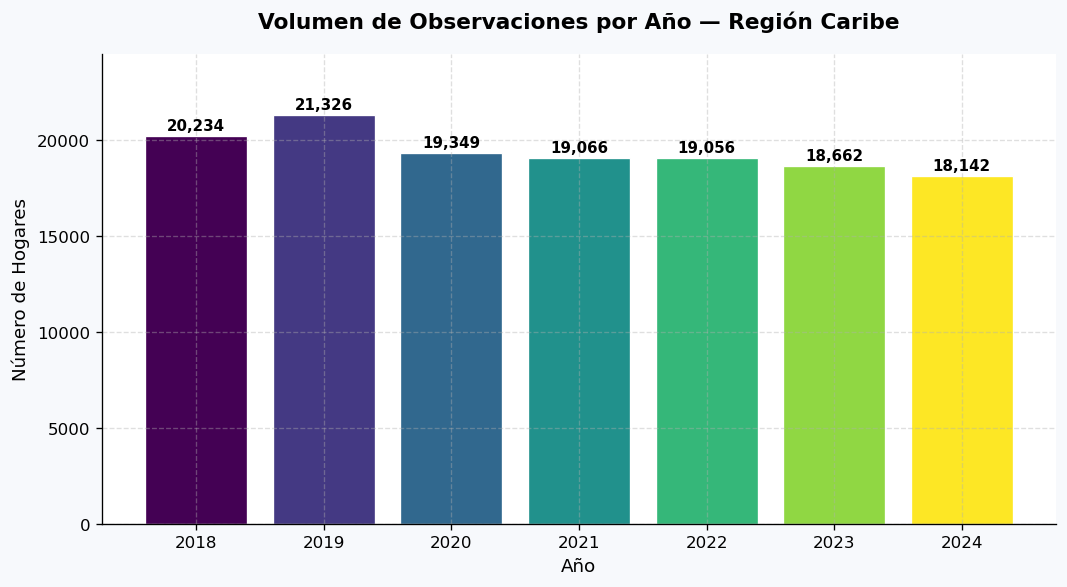


Rango: 18,142 – 21,326 hogares/año
Variación: 16.4% respecto a la media


In [18]:
# Distribución de observaciones por año
# Permite verificar estabilidad temporal de la muestra.
conteo_anual = df.groupby('año').size()

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F7F9FC')

# Paleta viridis discreta para los años
n_years = len(conteo_anual)
colors_años = [VIRIDIS(i / (n_years - 1)) for i in range(n_years)]

bars = ax.bar(conteo_anual.index.astype(str), conteo_anual.values,
              color=colors_años, edgecolor='white', linewidth=0.8)

# Etiqueta de frecuencia sobre cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
            f"{int(bar.get_height()):,}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Volumen de Observaciones por Año — Región Caribe",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Número de Hogares", fontsize=11)
ax.set_ylim(0, conteo_anual.max() * 1.15)

plt.tight_layout()
plt.show()

print(f"\nRango: {conteo_anual.min():,} – {conteo_anual.max():,} hogares/año")
print(f"Variación: {((conteo_anual.max() - conteo_anual.min()) / conteo_anual.mean() * 100):.1f}% respecto a la media")

> La recolección respecto a la cantidad de datos tomados por año ha sido constante manteniendose, entre 17.5k y 20k por cada año por lo que es representativo de cada año

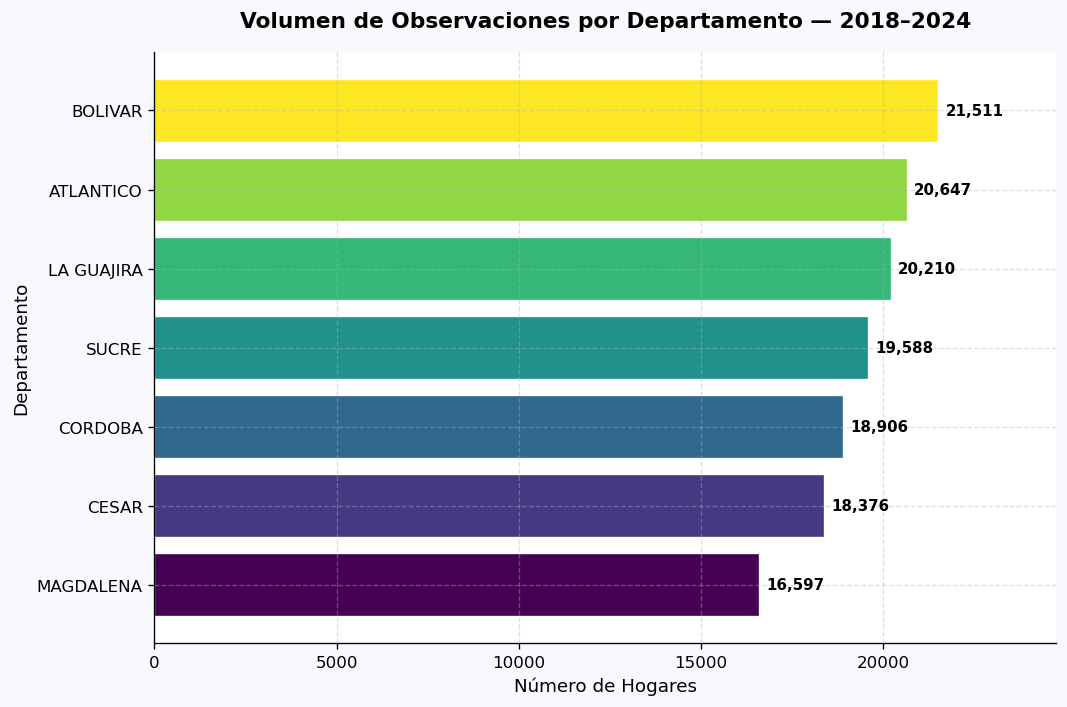

In [19]:
# Distribución de observaciones por departamento
# Confirma representatividad geográfica del dataset.
conteo_dep = df.groupby('departamento_nombre').size().sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#F7F9FC')

# Paleta viridis discreta para los departamentos
n_dep = len(conteo_dep)
colors_dep = [VIRIDIS(i / (n_dep - 1)) for i in range(n_dep)]

bars = ax.barh(conteo_dep.index, conteo_dep.values,
               color=colors_dep, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=9, fontweight='bold')

ax.set_title("Volumen de Observaciones por Departamento — 2018–2024",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Número de Hogares", fontsize=11)
ax.set_ylabel("Departamento", fontsize=11)
ax.set_xlim(0, conteo_dep.max() * 1.15)

plt.tight_layout()
plt.show()


> La cantidad de datos tomados por departamento es similar, siendo magadalena el departamento con menor representación sin embargo sigue siendo lo suficientemente fuerte para que sea representativo

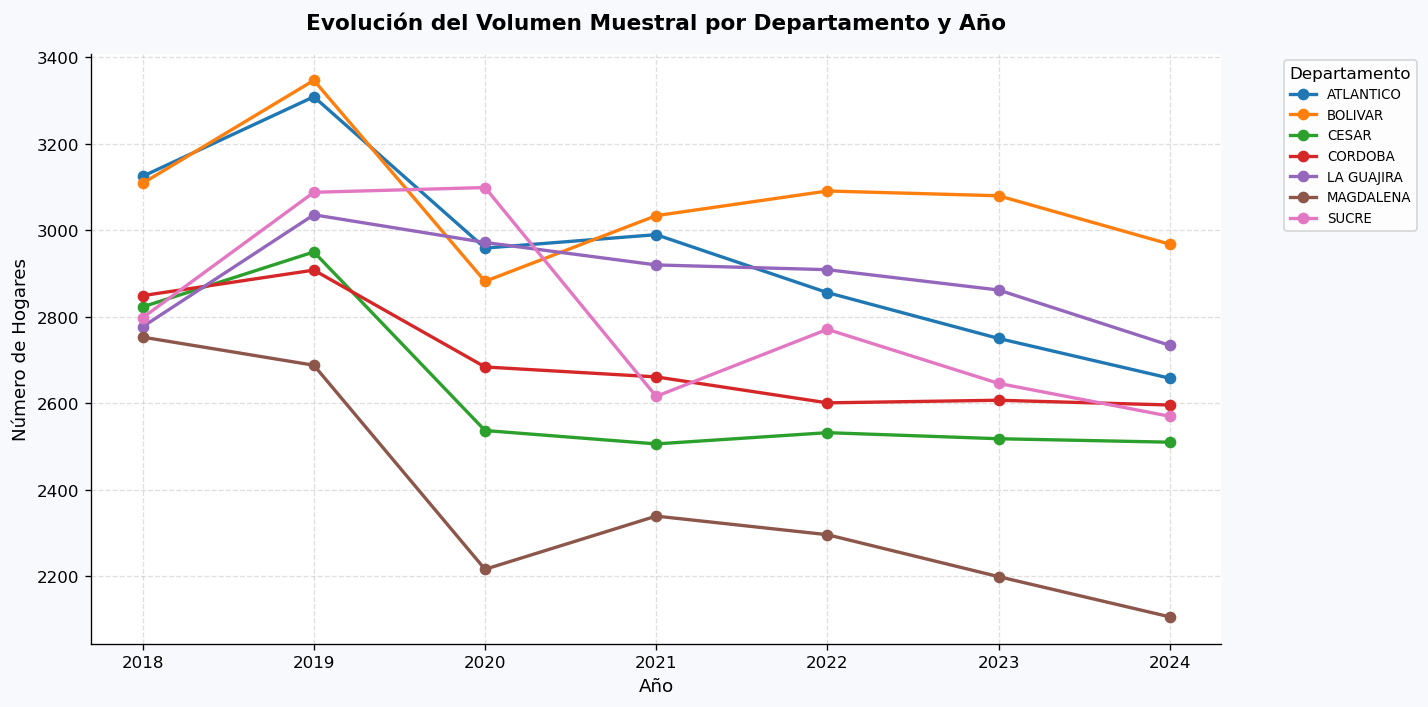

In [20]:
# Cobertura cruzada: año × departamento
# Verifica que todos los departamentos estén presentes en todos los años.
# Un valor en blanco indicaría ausencia de datos para ese cruce específico.
tabla_cruce = df.groupby(['año', 'departamento_nombre']).size().reset_index(name='n')

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F7F9FC')

for dep in tabla_cruce['departamento_nombre'].unique():
    subset = tabla_cruce[tabla_cruce['departamento_nombre'] == dep]
    ax.plot(subset['año'], subset['n'], marker='o', linewidth=2, label=dep)

ax.set_title("Evolución del Volumen Muestral por Departamento y Año",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Número de Hogares", fontsize=11)
ax.legend(title='Departamento', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


> Los datos son confiables para el análisis de tendencias generales y comparaciones entre departamentos. La ligera reducción en la muestra reciente no invalida los resultados, pero requiere que ser cuidadoso al comprar registros de diferentes proporciones

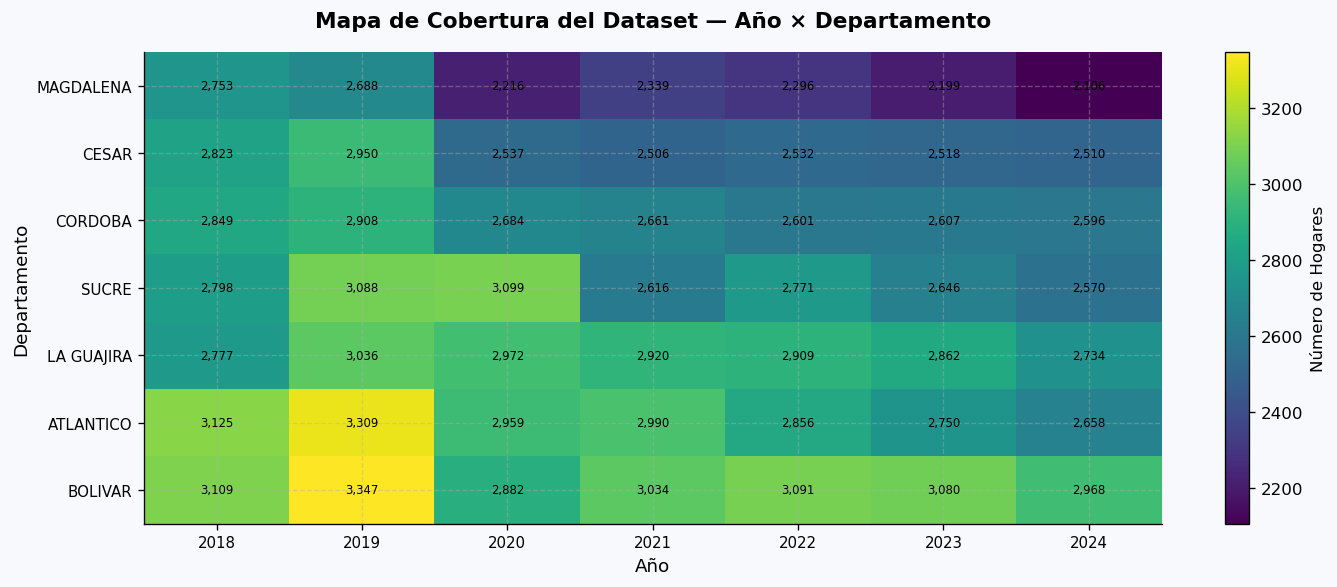

In [21]:
# Mapa de calor de cobertura — visualización matricial año × departamento
# Permite identificar de un vistazo cualquier año o departamento sin datos.
cobertura = df.groupby(['año', 'departamento_nombre']).size().unstack(fill_value=0)
cobertura = cobertura.loc[:, cobertura.sum().sort_values().index]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#F7F9FC')

im = ax.imshow(cobertura.T, aspect='auto', cmap='viridis')

# Anotaciones con el conteo exacto
for i, dep in enumerate(cobertura.columns):
    for j, year in enumerate(cobertura.index):
        ax.text(j, i, f"{cobertura.loc[year, dep]:,}",
                ha='center', va='center', fontsize=7,
                color='white' if cobertura.loc[year, dep] < cobertura.values.max() * 0.6 else 'black')

plt.colorbar(im, ax=ax, label='Número de Hogares')
ax.set_yticks(range(len(cobertura.columns)))
ax.set_yticklabels(cobertura.columns, fontsize=9)
ax.set_xticks(range(len(cobertura.index)))
ax.set_xticklabels(cobertura.index, rotation=0, fontsize=9)

ax.set_title("Mapa de Cobertura del Dataset — Año × Departamento",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Departamento", fontsize=11)

plt.tight_layout()
plt.show()



>  - Existe cobertura completa para todos los departamentos en todos los años del periodo
>  - La reducción marginal en años recientes no compromete la validez de los análisis de tendencia.

---
## 1.8. Análisis de Multicolinealidad entre Variables de Privación

Antes de avanzar hacia el modelamiento predictivo, es fundamental evaluar el grado de correlación lineal entre las 15 variables indicadoras del IPM. Este análisis es relevante por dos razones:

1. **Diseño metodológico del IPM:** Las privaciones están construidas para medir dimensiones conceptualmente distintas del bienestar. Se espera una correlación baja entre dimensiones, aunque puede haber correlación moderada dentro de la misma dimensión (e.g., `pisos` y `acueducto` en vivienda).

2. **Implicaciones para el modelamiento:** Alta multicolinealidad entre predictores puede inflar la varianza de los coeficientes en modelos lineales. Este diagnóstico justifica —o no— el uso de regularización (Ridge, Lasso, ElasticNet) en el Notebook 3.

La matriz que se genera a continuación es la misma reportada en el artículo científico (Figura 3).


In [22]:
# Definición de variables indicadoras y etiquetas legibles para el gráfico
privaciones = [
    'paredes', 'pisos', 'alcantarillado', 'acueducto',
    'empleo_formal', 'desempleo_larga_duracion',
    'barreras_acceso_salud', 'aseguramiento_salud',
    'trabajo_infantil', 'atencion_integral',
    'inasistencia_escolar', 'rezago_escolar',
    'alfabetismo', 'logro_educativo', 'hacinamiento'
]

etiquetas = {
    'paredes':                  'Paredes',
    'pisos':                    'Pisos',
    'hacinamiento':             'Hacinamiento',
    'alcantarillado':           'Alcantarillado',
    'acueducto':                'Acueducto',
    'empleo_formal':            'Empleo formal',
    'desempleo_larga_duracion': 'Desempleo largo',
    'trabajo_infantil':         'Trabajo infantil',
    'barreras_acceso_salud':    'Barreras salud',
    'aseguramiento_salud':      'Aseguramiento',
    'inasistencia_escolar':     'Inasistencia',
    'rezago_escolar':           'Rezago escolar',
    'alfabetismo':              'Alfabetismo',
    'logro_educativo':          'Logro educativo',
    'atencion_integral':        'Atención integral',
}

# Cálculo de la matriz de correlación de Pearson (sin ponderar)
# Nota: la versión ponderada por fex_c se calcula en el Notebook 2 (EDA)
# donde se analiza el impacto de los factores de expansión sobre los resultados.
corr_matrix = df[privaciones].corr()
corr_matrix.index   = [etiquetas[p] for p in privaciones]
corr_matrix.columns = [etiquetas[p] for p in privaciones]

print(f"Matriz de correlación calculada: {corr_matrix.shape}")


Matriz de correlación calculada: (15, 15)


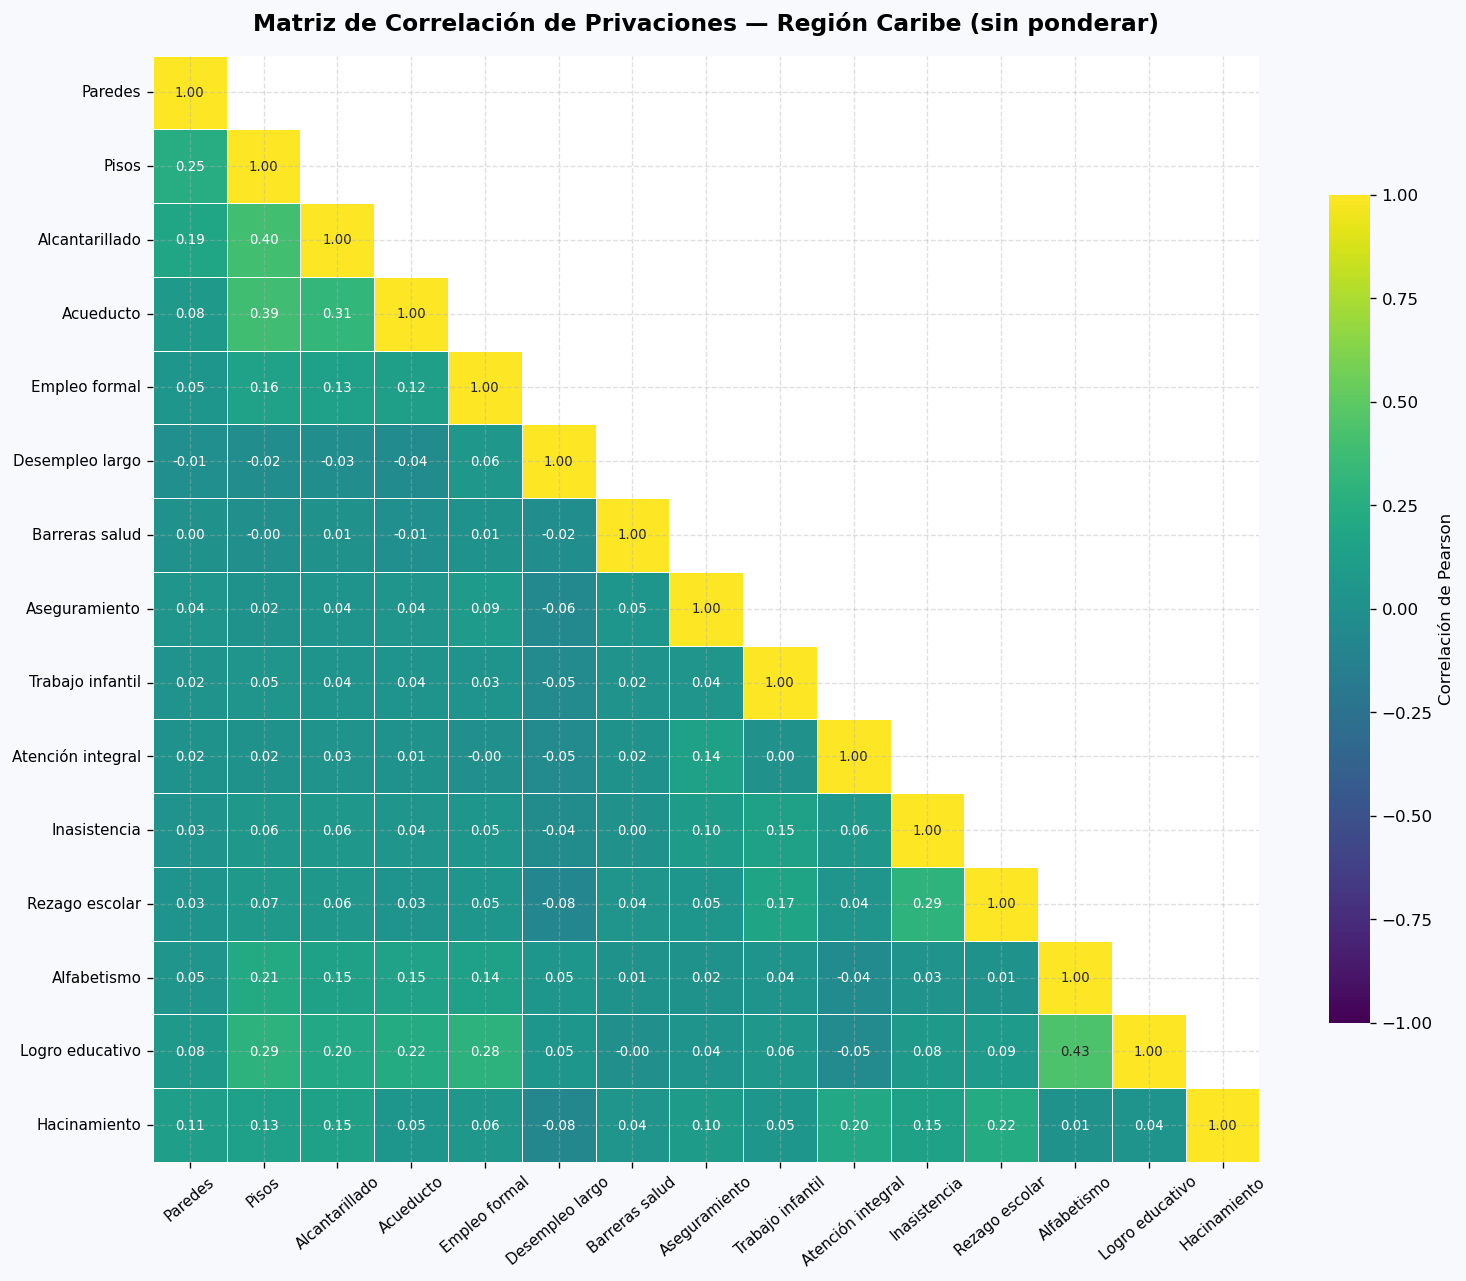

In [23]:
# Visualización de la matriz de correlación — triángulo inferior
# Se oculta el triángulo superior para evitar redundancia visual.
# Paleta viridis para consistencia con el resto del proyecto.
fig, ax = plt.subplots(figsize=(13, 11))
fig.patch.set_facecolor('#F7F9FC')

# Máscara para triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='viridis',
    vmin=-1, vmax=1,
    center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.7},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación de Privaciones — Región Caribe (sin ponderar)",
    fontsize=14, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()


In [24]:
# Identificación de pares con correlación moderada o alta
# Umbral: |r| > 0.20 para detectar relaciones estadísticamente relevantes.
# Este diagnóstico orienta las decisiones de regularización en el Notebook 3.
threshold = 0.20

corr_stack = (
    corr_matrix
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_stack.columns = ['Variable 1', 'Variable 2', 'Correlación']
corr_stack = corr_stack[corr_stack['Correlación'].abs() > threshold]
corr_stack = corr_stack.sort_values('Correlación', ascending=False)

print(f"Pares con |correlación| > {threshold}:")
print(corr_stack.to_string(index=False))
print()



Pares con |correlación| > 0.2:
     Variable 1     Variable 2  Correlación
Logro educativo    Alfabetismo     0.431755
 Alcantarillado          Pisos     0.395382
      Acueducto          Pisos     0.389467
      Acueducto Alcantarillado     0.314383
 Rezago escolar   Inasistencia     0.289654
Logro educativo          Pisos     0.285148
Logro educativo  Empleo formal     0.282418
          Pisos        Paredes     0.249215
Logro educativo      Acueducto     0.221479
   Hacinamiento Rezago escolar     0.221043
    Alfabetismo          Pisos     0.214514



 > La matriz de correlación muestra una baja dependencia lineal entre la mayoría de las variables, lo que sugiere que cada privación captura aspectos distintos del fenómeno de pobreza multidimensional. Este comportamiento es consistente con la naturaleza del IPM, ya que sus dimensiones buscan medir diferentes formas de vulnerabilidad social.
>
> Las asociaciones más visibles aparecen entre:
>
 > - **Acueducto y Pisos**, relacionadas con las condiciones de vivienda e infraestructura básica.
 > - **Alfabetismo y Logro Educativo**, variables que reflejan distintas dimensiones del capital humano y el acceso a  > oportunidades educativas.
>
 > Fuera de estas relaciones, no se observan correlaciones elevadas que sugieran redundancia significativa entre indicadores.
>
 > A partir de este diagnóstico, el análisis exploratorio se divide por dimensiones del IPM para estudiar cómo cada privación se relaciona con la condición de pobreza multidimensional. Como primer paso, se comparan los hogares clasificados como **No Pobres (0)** y **Pobres (1)** en cada una de las variables que conforman el índice.

---
## 1.9 Resumen y Próximos Pasos

Este notebook estableció la base analítica del proyecto:

| Tarea | Estado |
|-------|--------|
| Carga e integración del dataset (2018–2024) | ✓ |
| Corrección de tipos de datos (fex_c, fexp, ipm) | ✓ |
| Validación de integridad: nulos y duplicados | ✓ |
| Verificación de cobertura temporal y geográfica | ✓ |
| Análisis de multicolinealidad entre variables del IPM | ✓ |

**Hallazgos estructurales relevantes:**

- El dataset contiene ~136 000 observaciones a nivel de hogar, distribuidas de forma estable entre 17 500 y 20 000 registros por año para cada uno de los 7 departamentos.
- La variable `ipm` tiene un valor promedio de 0.25, con la mayoría de hogares en el rango bajo-moderado de privación (0–0.34), pero con una cola derecha que refleja hogares con privaciones severas.
- Las correlaciones entre variables indicadoras son bajas a moderadas (máximo ~0.48), validando el diseño multidimensional del índice y justificando el uso de regularización Ridge como estrategia antisobreajuste en el modelamiento.

**Próximo notebook:** `02_EDA.ipynb` — Análisis Exploratorio de Datos: distribuciones de privación por dimensión, evolución temporal del IPM, ciclos intergeneracionales de pobreza e identificación de patrones regionales de vulnerabilidad.
